<a href="https://colab.research.google.com/github/akshat-mishra-ds/DeepFER-Facial-Emotion-Recognition/blob/main/DeepFER_Facial_Emotion_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - DeepFER: Facial Emotion Recognition Using Deep Learning



##### **Project Type**    - Deep Learning
##### **Contribution**    - Individual
##### **Submitted by -** Akshat Mishra

# **Project Summary -**

**DeepFER: Facial Emotion Recognition Using Deep Learning** aims to develop a robust and efficient system for recognizing emotions from facial expressions using advanced deep learning techniques. This project leverages Convolutional Neural Networks (CNNs) and Transfer Learning to accurately classify emotions such as happiness, sadness, anger, surprise, and more from images of human faces. The system will be trained on a diverse dataset of facial images, employing data augmentation and fine-tuning methods to enhance its performance. By integrating state-of-the-art computer vision algorithms and neural network architectures, DeepFER seeks to achieve high accuracy and real-time processing capabilities. The ultimate goal is to create a versatile tool that can be applied in various fields, including human-computer interaction, mental health monitoring, and customer service, enhancing the way machines understand and respond to human emotions.

# **GitHub Link -**

https://github.com/akshat-mishra-ds/DeepFER-Facial-Emotion-Recognition

# **Problem Statement**


The objective of this project is to develop a robust Facial Emotion Recognition system capable of classifying facial expressions into seven emotion categories:
- Angry,
- Disgust,
- Fear,
- Happy,
- Neutral,
- Sad, and
- Surprise.

The model will leverage deep learning techniques, image preprocessing, data augmentation, and transfer learning to achieve accurate emotion classification.

The final system will be deployed through a Streamlit application, allowing users to upload facial images and receive real-time emotion predictions.


# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [86]:
# Import Libraries
# ==================================================

# Basic libraries
# ----------------
import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd

# Visualization libraries
# -------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning libraries
# -------------------------
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

# Data splitting
# ----------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

### Dataset Loading

In [3]:
# Mount Drive
# -------------------------------

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load Dataset
# ----------------------
dataset_path = "/content/drive/MyDrive/Specialization projects/DeepFER: Facial Emotion Recognition/Face Emotion Recognition Dataset/images/train"

In [5]:
# Verify Emotion Classes
# --------------------------------

emotion_classes = os.listdir(dataset_path)

print("Emotion Classes:\n")

for emotion in emotion_classes:
    print(emotion)

Emotion Classes:

surprise
sad
neutral
fear
angry
happy
disgust


### Dataset Rows & Columns count

In [6]:
# Dataset Rows & Columns count
# -----------------------------------

image_count = {}

for emotion in emotion_classes:

    folder_path = os.path.join(dataset_path, emotion)

    image_count[emotion] = len(os.listdir(folder_path))

image_count

{'surprise': 3205,
 'sad': 4938,
 'neutral': 4982,
 'fear': 4103,
 'angry': 3993,
 'happy': 7164,
 'disgust': 436}

### Dataset Summary Table

In [7]:
# Create Dataset Summary Table
# -------------------------------

dataset_summary = pd.DataFrame(
    image_count.items(),
    columns=['Emotion','Image Count']
)

dataset_summary

,Emotion,Image Count
0,surprise,3205
1,sad,4938
2,neutral,4982
3,fear,4103
4,angry,3993
5,happy,7164
6,disgust,436


### Dataset Information

In [8]:
# Dataset Info
# ----------------------

print("Total Emotion Classes :", len(emotion_classes))
print("Total Images :", dataset_summary['Image Count'].sum())

Total Emotion Classes : 7
Total Images : 28821


#### Duplicate Values

In [9]:
# Dataset Duplicate Value Count
# ---------------------------------------

duplicate_count = 0

for emotion in emotion_classes:

    folder = os.path.join(dataset_path, emotion)

    files = os.listdir(folder)

    if len(files) != len(set(files)):
        duplicate_count += 1

print("Duplicate Folder Count :", duplicate_count)

Duplicate Folder Count : 0


For image datasets, we check duplicate filenames.

#### Missing Values/Null Values

In [10]:
# Missing Values
# ------------------------

missing_images = 0

for emotion in emotion_classes:

    folder = os.path.join(dataset_path, emotion)

    for image in os.listdir(folder):

        path = os.path.join(folder,image)

        img = cv2.imread(path)

        if img is None:
            missing_images += 1

print("Unreadable Images :", missing_images)

Unreadable Images : 0


**For image datasets, missing values means unreadable images.**

### What did you know about your dataset?

Here's a short summary of the dataset:

**Dataset Type:** Facial Emotion Recognition dataset

**Total Emotion Classes: 7**
- Happy
- Disgust
- Fear
- Surprise
- Neutral
- Sad
- Angry

**Total Images:** 28,821

**Class Distribution:**
- Happy: 7,164
- Neutral: 4,982
- Sad: 4,938
- Fear: 4,103
- Angry: 3,993
- Surprise: 3,205
- Disgust: 436

**Data Quality Checks:**
- Duplicate images/folders: 0
- Unreadable/Corrupted images: 0
- Missing images: 0 (based on the checks performed)

**Key Observation:** The Happy class having the highest number of images (7,164) and the Disgust class having the fewest (436). This class imbalance should be handled during model training using techniques such as data augmentation, class weights, or oversampling.

## ***2. Exploratory Data Analysis***

### Emotion Class Distribution

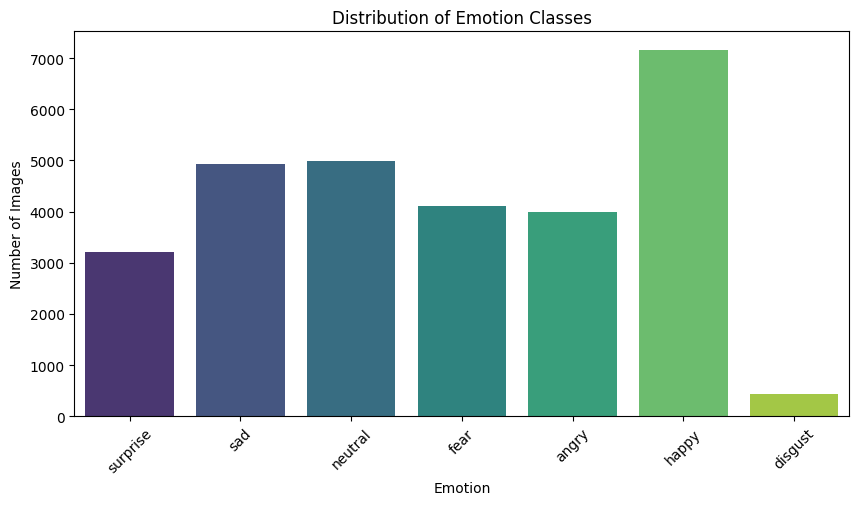

In [11]:
# Visualizing emotion distribution
# (Understand whether the dataset is balanced or imbalanced)
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

sns.barplot(
    x=dataset_summary['Emotion'],
    y=dataset_summary['Image Count'], palette='viridis'
)

plt.title("Distribution of Emotion Classes")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.show()

The bar chart shows the number of images available for each emotion class.
- The Happy class contains the highest number of images (7,164), while Disgust contains the fewest (436).

Most other classes have between 3,000 and 5,000 images. This indicates that the dataset is imbalanced, with some emotions being significantly more represented than others.

### Percentage Distribution of Emotion Classes

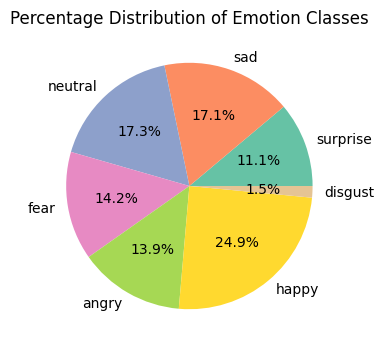

In [12]:
# Understand the proportion of each emotion.
# ---------------------------------------------

plt.figure(figsize=(8, 4))

plt.pie(
    dataset_summary['Image Count'],
    labels = dataset_summary['Emotion'],
    autopct = '%1.1f%%',
    colors = plt.cm.Set2.colors
)

plt.title("Percentage Distribution of Emotion Classes")

plt.show()

The pie chart illustrates the percentage contribution of each emotion class to the overall dataset.
- Happy accounts for approximately 24.9% of all images, whereas Disgust contributes only 1.5%.

The remaining classes contribute between 11% and 17% each. This confirms the presence of class imbalance, which may affect model performance if not handled properly.

### Visualizing Sample Images from Each Emotion

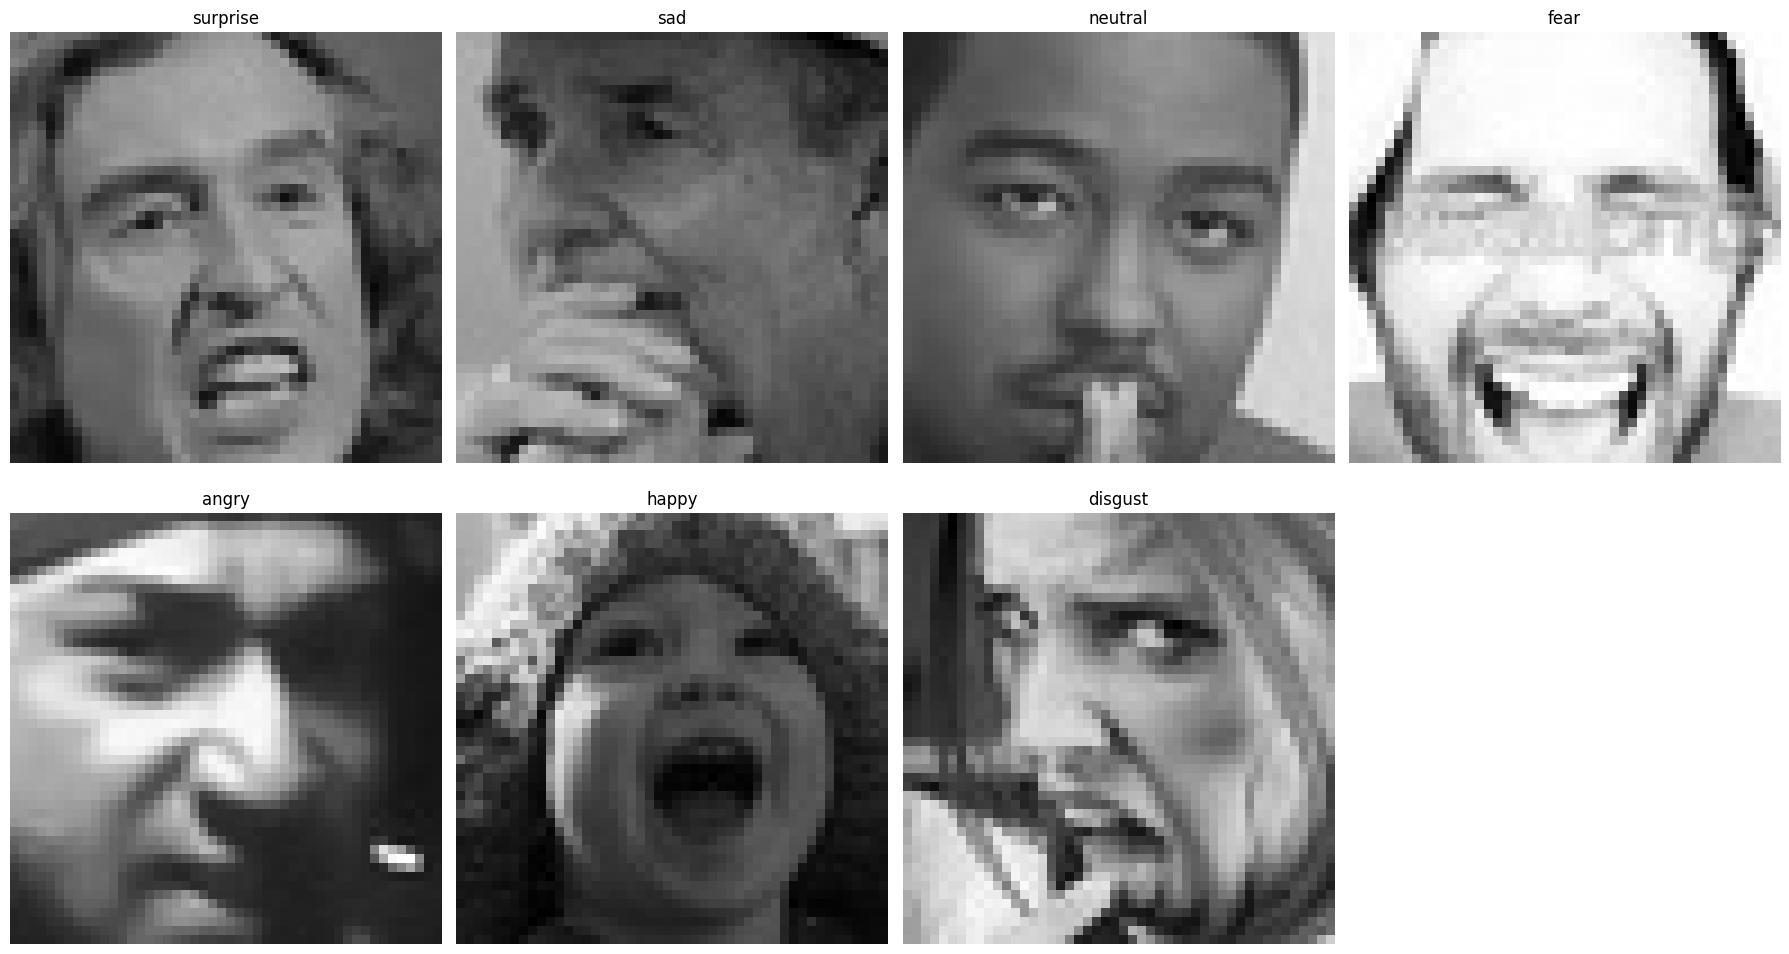

In [13]:
# Understand facial appearance differences among emotion classes
# ----------------------------------------------------------------

plt.figure(figsize=(18,10))

for i, emotion in enumerate(emotion_classes):

    folder = os.path.join(dataset_path, emotion)

    image_name = os.listdir(folder)[0]
    image_path = os.path.join(folder, image_name)
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title(emotion)
    plt.axis('off')

plt.tight_layout()
plt.show()

One representative image from each emotion class was visualized to understand facial expression characteristics. Distinct facial features such as smiling, frowning, widened eyes, and raised eyebrows can be observed across different emotional categories.

### Random Image Visualization

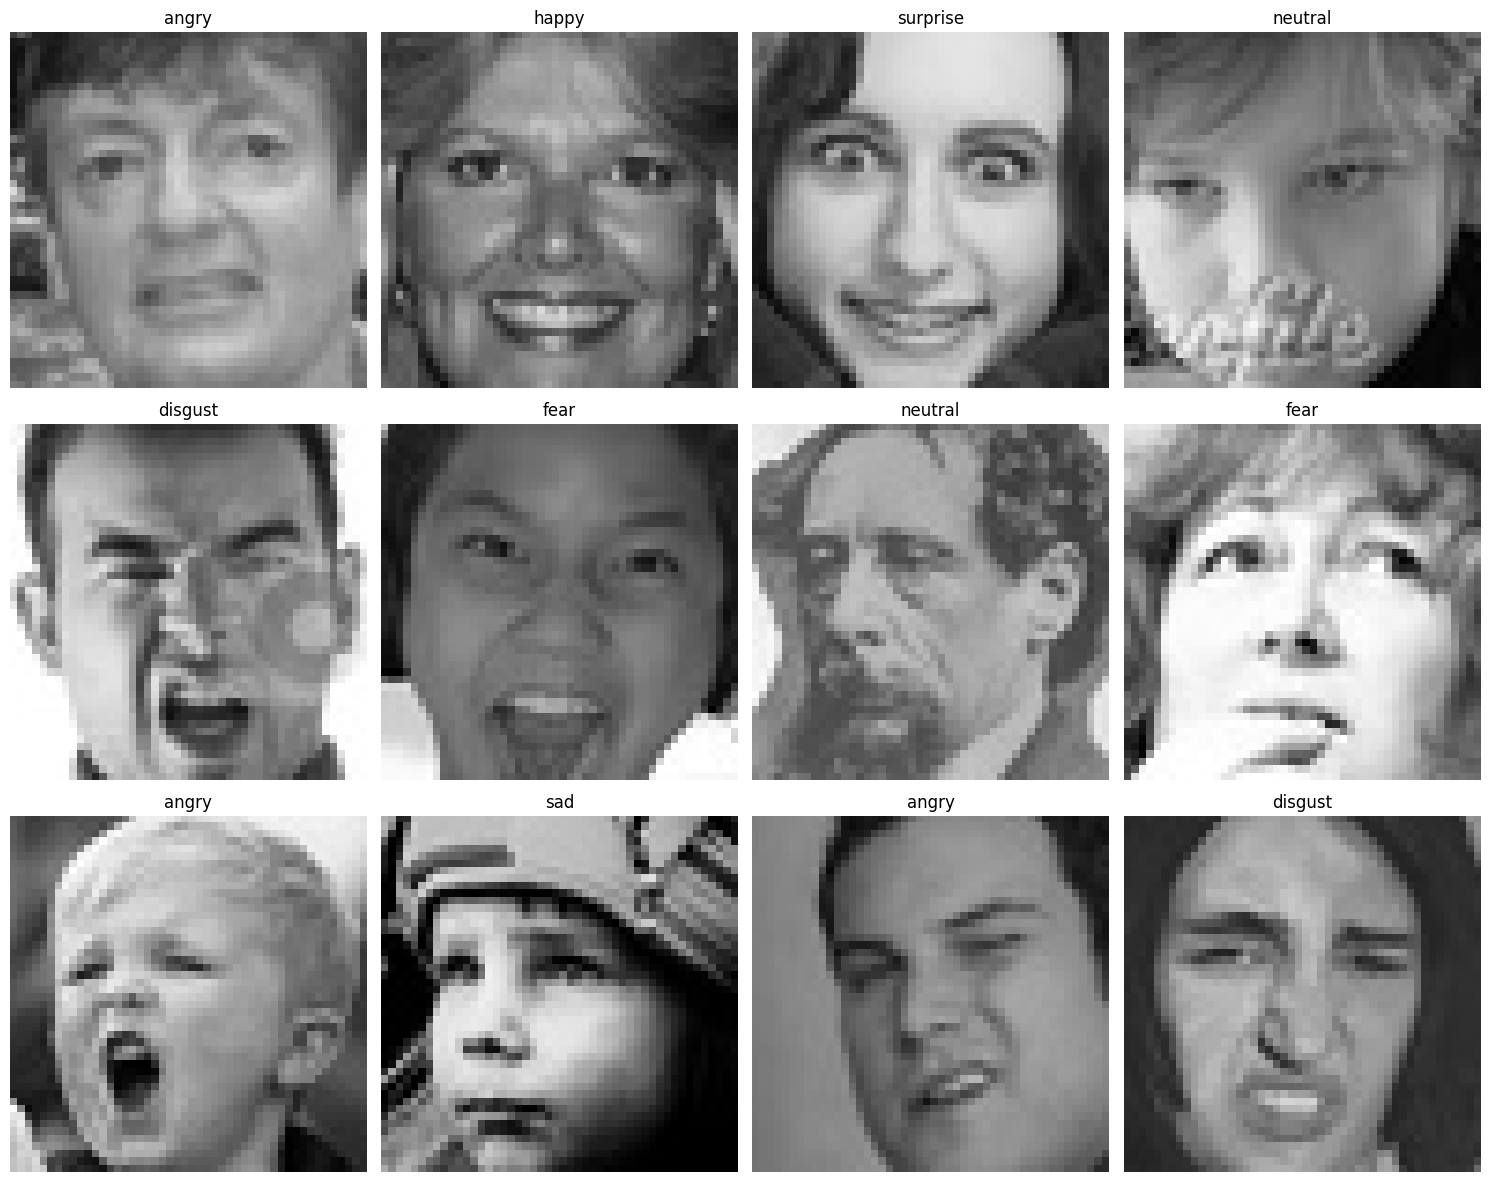

In [14]:
# Inspect Dataset Diversity
# -----------------------------

plt.figure(figsize=(15,12))

for i in range(12):

    emotion = random.choice(emotion_classes)

    folder = os.path.join(dataset_path, emotion)

    image_name = random.choice(os.listdir(folder))
    image_path = os.path.join(folder,image_name)
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,4,i+1)
    plt.imshow(img)
    plt.title(emotion)
    plt.axis('off')

plt.tight_layout()

plt.show()

Random samples were visualized to examine variation in facial appearance, lighting conditions, facial orientation, and expression intensity. Such diversity helps improve the robustness of deep learning models.

### Image Size Analysis

In [15]:
# Verify whether images have consistent dimensions
# -----------------------------------------------------

image_heights = []
image_widths = []

for emotion in emotion_classes:

    folder = os.path.join(dataset_path, emotion)

    sample_images = os.listdir(folder)[:50]

    for image in sample_images:

        path = os.path.join(folder,image)
        img = cv2.imread(path)

        if img is not None:

            h,w,_ = img.shape
            image_heights.append(h)
            image_widths.append(w)

In [16]:
print("Minimum Height :", min(image_heights))
print("Maximum Height :", max(image_heights))

print("Minimum Width :", min(image_widths))
print("Maximum Width :", max(image_widths))

Minimum Height : 48
Maximum Height : 48
Minimum Width : 48
Maximum Width : 48


### Image Dimension Distribution

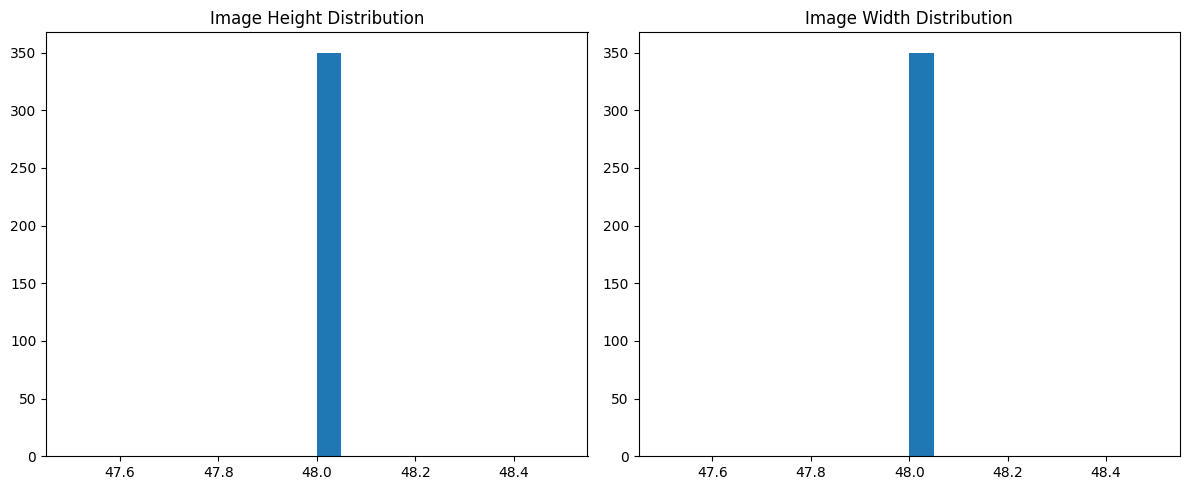

In [17]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(image_heights,bins=20)
plt.title("Image Height Distribution")

plt.subplot(1,2,2)
plt.hist(image_widths,bins=20)
plt.title("Image Width Distribution")

plt.tight_layout()

plt.show()

The height and width distributions show that all sampled images have identical dimensions of 48 × 48 pixels.

**The minimum and maximum values for both height and width are 48, indicating complete consistency across the dataset.**

This uniform image size eliminates the need for resizing during preprocessing and ensures compatibility with deep learning models.

### Pixel Intensity Distribution

In [18]:
# Pixel Intensity Distribution
# ------------------------------

sample_pixels = []

for emotion in emotion_classes:

    folder = os.path.join(dataset_path, emotion)
    sample_images = os.listdir(folder)[:100]

    for image in sample_images:

        path = os.path.join(folder,image)
        img = cv2.imread(path,0)

        if img is not None:

            sample_pixels.extend(img.flatten())

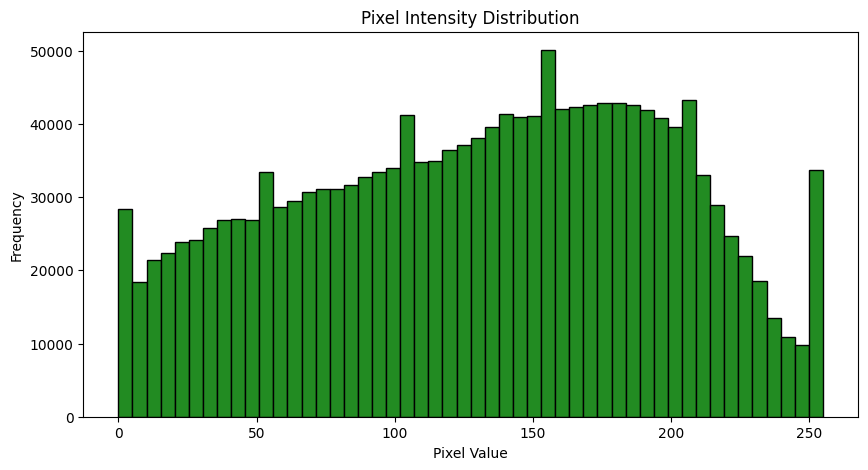

In [19]:
plt.figure(figsize=(10,5))

plt.hist(sample_pixels, bins=50, color='forestgreen', edgecolor='black')

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.show()

The pixel intensity histogram shows the distribution of grayscale **pixel values ranging from 0 (black) to 255 (white)**. The pixel values are spread across the entire intensity range, indicating good variation in brightness and contrast among images.

**This diversity in pixel intensities suggests that the dataset contains rich visual information useful for emotion recognition.**

### Verify Image Color Channels

In [20]:
# Since this is an emotion recognition dataset,
# proving that images are grayscale is useful.
# ---------------------------------------------------

sample_path = os.path.join(
    dataset_path,
    emotion_classes[0],
    os.listdir(os.path.join(dataset_path, emotion_classes[0]))[0]
)

img = cv2.imread(sample_path)

print("Image Shape :", img.shape)

Image Shape : (48, 48, 3)


The sample image has a shape of (48, 48, 3), indicating that it contains three color channels.

## ***3. Data Wrangling***

### Read All Images and Create Labels

In [21]:
# Create the image dataset (X) and target labels (y)
# Empty lists to store images and labels
# -------------------------------------------------------

images = []
labels = []

Two empty lists were created to store image data and their corresponding emotion labels. These lists will later be converted into NumPy arrays for deep learning model training.

In [22]:
# Reading images from each emotion folder
# --------------------------------------------

for emotion in emotion_classes:

    folder_path = os.path.join(dataset_path, emotion)

    for image_name in os.listdir(folder_path):

        image_path = os.path.join(folder_path, image_name)

        # Read image
        img = cv2.imread(image_path)

        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Store image
        images.append(img)

        # Store corresponding label
        labels.append(emotion)

Images from all emotion categories were loaded into memory. Each image was assigned its corresponding emotion label based on the folder name. Additionally, images were converted from BGR format to RGB format because OpenCV loads images in BGR format by default, while visualization and deep learning frameworks commonly use RGB format.

In [23]:
# Total Images Loaded
# --------------------

print("Total Images Loaded :", len(images))
print("Total Labels Loaded :", len(labels))

Total Images Loaded : 28821
Total Labels Loaded : 28821


### Convert Lists into NumPy Arrays

In [24]:
X = np.array(images)
y = np.array(labels)

The image and label lists were converted into NumPy arrays to improve computational efficiency and enable compatibility with TensorFlow and Keras deep learning frameworks because Deep learning models cannot directly work with Python lists.

In [25]:
# Dataset Shape Verification
# ----------------------------

print("Feature Dataset Shape :", X.shape)
print("Target Dataset Shape :", y.shape)

Feature Dataset Shape : (28821, 48, 48, 3)
Target Dataset Shape : (28821,)


In [26]:
# Verify Data Type
# --------------------

print("Image Data Type :", X.dtype)
print("Label Data Type :", y.dtype)

Image Data Type : uint8
Label Data Type : <U8


The dataset uses a standard image format - **`uint8`** and clearly defined string-based emotion labels - **`<U8`**, making it well-structured and suitable for emotion classification tasks after appropriate preprocessing and label encoding.

In [27]:
# Verify Class Labels
# ----------------------

print("Unique Emotion Classes :")
np.unique(y)

Unique Emotion Classes :


array(['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise'],
      dtype='<U8')

The unique target labels were inspected to confirm that all seven emotion categories were successfully loaded into the dataset.

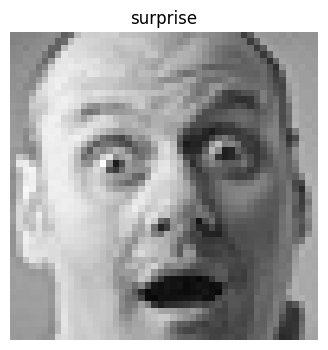

In [28]:
# Random Verification of Loaded Dataset
# ---------------------------------------

random_index = np.random.randint(0, len(X))

plt.figure(figsize=(4,4))

plt.imshow(X[random_index])
plt.title(y[random_index])
plt.axis('off')

plt.show()

### What all manipulations have you done and insights you found?

During the data wrangling process, all facial images were loaded from their respective emotion folders and organized into feature (`X`) and target (`y`) datasets. Images were converted from BGR to RGB format to ensure consistency with visualization and deep learning requirements. The image and label data were then transformed into NumPy arrays for efficient processing.

**Insights Found :**

* No missing or corrupted images were found in the dataset.
* All images had a consistent size of **48×48 pixels** with **3 color channels (RGB)**.
* The dataset contained all seven emotion categories successfully.
* The number of images and labels matched perfectly, confirming correct dataset construction.
* The dataset was clean, well-structured, and ready for preprocessing and model training.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [29]:
# Chart - 1 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 2

In [30]:
# Chart - 2 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 3

In [31]:
# Chart - 3 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

In [32]:
# Chart - 4 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

In [33]:
# Chart - 5 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

In [34]:
# Chart - 6 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

In [35]:
# Chart - 7 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

In [36]:
# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [37]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [38]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [39]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [40]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [41]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [42]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [43]:
# Pair Plot visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***6. Feature Engineering & Data Pre-processing***

### Label Encoding

In [44]:
# Creating Label Encoder
# --------------------------

label_encoder = LabelEncoder()

# Converting emotion labels into numerical labels
# -------------------------------------------------

y_encoded = label_encoder.fit_transform(y)

In [45]:
print("Encoded Labels Sample:")

y_encoded[:10]

Encoded Labels Sample:


array([6, 6, 6, 6, 6, 6, 6, 6, 6, 6])

In [46]:
# Emotion Mapping
# ----------------------

emotion_mapping = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
)

emotion_mapping

{np.str_('angry'): np.int64(0),
 np.str_('disgust'): np.int64(1),
 np.str_('fear'): np.int64(2),
 np.str_('happy'): np.int64(3),
 np.str_('neutral'): np.int64(4),
 np.str_('sad'): np.int64(5),
 np.str_('surprise'): np.int64(6)}

Deep Learning models cannot understand text labels so the categorical emotion labels were converted into numerical values using Label Encoding. This transformation is necessary because deep learning models require numerical target values for training.

### One-Hot Encoding

In [47]:
# One-Hot Encoding
# ----------------------

y_categorical = to_categorical(y_encoded)

In [48]:
print("Shape After One-Hot Encoding:")

y_categorical.shape

Shape After One-Hot Encoding:


(28821, 7)

In [49]:
# Sample Encoded Label
# ---------------------

y_categorical[0]

array([0., 0., 0., 0., 0., 0., 1.])

The encoded target labels were converted into one-hot vectors. This representation is required for multi-class classification tasks using the Softmax activation function.

### Train-Test Split

In [50]:
# Separate unseen data for final evaluation
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_categorical,
    test_size = 0.20,
    random_state = 42,
    stratify = y_encoded
)

In [51]:
print("Training Images :", X_train.shape)
print("Testing Images :", X_test.shape)

Training Images : (23056, 48, 48, 3)
Testing Images : (5765, 48, 48, 3)


The dataset was divided into training and testing subsets. The testing set was kept completely unseen during training and will be used for final model evaluation.

### Train-Validation Split

In [52]:
# Create validation data for monitoring model performance during training
# ----------------------------------------------------------------------------

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42
)

In [53]:
print("Training Shape :", X_train.shape)
print("Validation Shape :", X_val.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (18444, 48, 48, 3)
Validation Shape : (4612, 48, 48, 3)
Testing Shape : (5765, 48, 48, 3)


A validation dataset was created from the training data. This validation set will be used to monitor model performance during training and detect potential overfitting.

### Pixel Normalization

In [54]:
# Normalizing pixel values
# -------------------------------

X_train = X_train.astype('float32') / 255.0

X_val = X_val.astype('float32') / 255.0

X_test = X_test.astype('float32') / 255.0

In [55]:
print("Minimum Pixel Value :", X_train.min())
print("Maximum Pixel Value :", X_train.max())

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


Neural Networks perform better when values are scaled. Pixel values were normalized to a range between 0 and 1. Normalization improves numerical stability and helps the neural network converge more efficiently during training.

### Data Augmentation

In [56]:
# Increase training data diversity
# ------------------------------------

datagen = ImageDataGenerator(

    rotation_range = 15,
    width_shift_range = 0.10,
    height_shift_range = 0.10,
    zoom_range = 0.10,
    horizontal_flip = True,
    fill_mode = 'nearest'
)

In [57]:
# Compute any required statistics from the training data
# and prepare the augmentation pipeline

datagen.fit(X_train)

In [58]:
# Visualizing Augmented Images
# --------------------------------

sample_image = X_train[0]

sample_image = np.expand_dims(sample_image, axis=0)

augmented_images = datagen.flow(
    sample_image,
    batch_size=1
)

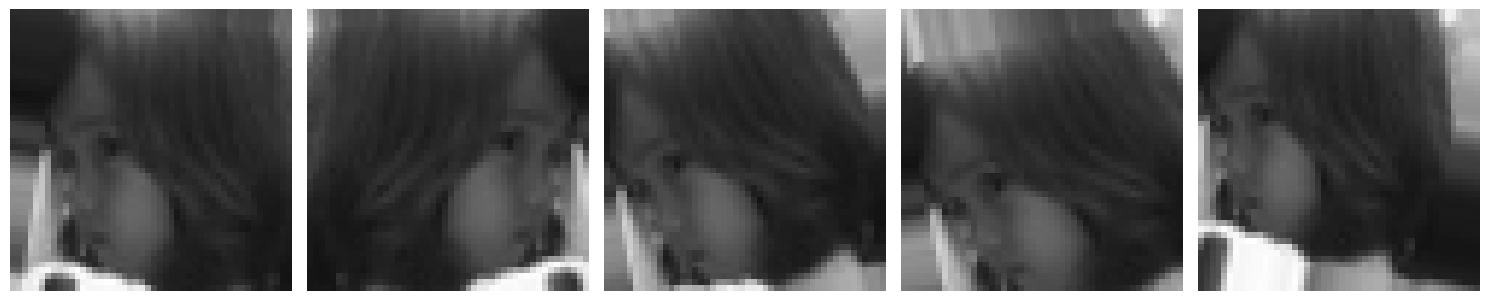

In [59]:
plt.figure(figsize=(15,5))

for i in range(5):

    plt.subplot(1,5,i+1)

    batch = next(augmented_images)
    plt.imshow(batch[0])
    plt.axis('off')

plt.tight_layout()

plt.show()

In [60]:
# ==================================
# Final Dataset Verification
# ==================================

print("Training Set Shape :", X_train.shape)
print("Validation Set Shape :", X_val.shape)
print("Testing Set Shape :", X_test.shape)
print("Target Shape :", y_train.shape)

Training Set Shape : (18444, 48, 48, 3)
Validation Set Shape : (4612, 48, 48, 3)
Testing Set Shape : (5765, 48, 48, 3)
Target Shape : (18444, 7)


## ***7. Deep Learning Model Implementation***

### **Model - 1 : Custom CNN**

In [61]:
# =================================
#  --- CNN Architecture Design ---
# =================================


cnn_model = Sequential()

# ==========================
# First Convolution Block
# ==========================

cnn_model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu',
        padding='same',
        input_shape=(48,48,3)
    )
)

cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(pool_size=(2,2)))
cnn_model.add(Dropout(0.25))


# ==========================
# Second Convolution Block
# ==========================

cnn_model.add(
    Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    )
)

cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(pool_size=(2,2)))
cnn_model.add(Dropout(0.25))


# ==========================
# Third Convolution Block
# ==========================

cnn_model.add(
    Conv2D(
        filters=256,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    )
)

cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(pool_size=(2,2)))
cnn_model.add(Dropout(0.30))


# ==========================
# Fourth Convolution Block
# ==========================

cnn_model.add(
    Conv2D(
        filters=512,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    )
)

cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(pool_size=(2,2)))
cnn_model.add(Dropout(0.30))


# ==========================
# Fully Connected Layers
# ==========================

cnn_model.add(Flatten())
cnn_model.add(Dense(256, activation='relu'))
cnn_model.add(Dropout(0.50))
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.30))

# Output Layer

cnn_model.add(Dense(7, activation='softmax'))

The CNN architecture consists of four convolutional blocks followed by fully connected layers. Convolutional layers extract hierarchical facial features, while pooling layers reduce dimensionality and computational complexity. Batch Normalization improves training stability, and Dropout layers help reduce overfitting. The final Softmax layer outputs probabilities across the seven emotion classes.

In [62]:
# Model Summary
# ------------------

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,768,519 (10.56 MB)

 Trainable params: 2,766,599 (10.55 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [63]:
# ============================
# Compile the CNN Model
# ============================

cnn_model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

The model was compiled using the Adam optimizer and categorical cross-entropy loss function. Adam is widely used because of its adaptive learning capability, while categorical cross-entropy is appropriate for multi-class classification problems.

In [64]:
# ==============================
# ---- Define Callbacks ----
# ==============================


# Early Stopping
# -----------------
early_stop = EarlyStopping(

    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Reduce Learning Rate
# ----------------------
reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.000001
)

# Save Best Model
# -----------------------
checkpoint = ModelCheckpoint(

    'best_cnn_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

Training callbacks were implemented to improve convergence and prevent overfitting. Early Stopping halts training when validation performance stops improving, ReduceLROnPlateau automatically lowers the learning rate when progress slows, and ModelCheckpoint saves the best-performing model.

In [76]:
# ============================
# Train the CNN Model
# ============================

history_cnn = cnn_model.fit(

    datagen.flow(
        X_train,
        y_train,
        batch_size=64
    ),

    validation_data=(X_val, y_val),

    epochs=30,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2525 - loss: 1.8144
Epoch 1: val_accuracy did not improve from 0.24068
289/289 ━━━━━━━━━━━━━━━━━━━━ 572s 2s/step - accuracy: 0.2513 - loss: 1.8121 - val_accuracy: 0.2392 - val_loss: 1.8172 - learning_rate: 2.0000e-04
Epoch 2/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2497 - loss: 1.8115
Epoch 2: val_accuracy did not improve from 0.24068
289/289 ━━━━━━━━━━━━━━━━━━━━ 569s 2s/step - accuracy: 0.2509 - loss: 1.8109 - val_accuracy: 0.2392 - val_loss: 1.8166 - learning_rate: 2.0000e-04
Epoch 3/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2552 - loss: 1.8081
Epoch 3: val_accuracy did not improve from 0.24068
289/289 ━━━━━━━━━━━━━━━━━━━━ 566s 2s/step - accuracy: 0.2509 - loss: 1.8105 - val_accuracy: 0.2392 - val_loss: 1.8123 - learning_rate: 2.0000e-04
Epoch 4/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2543 - loss: 1.8051
Epoch 4: val_accuracy did not improve from 0.24068
289/289 ━━━━━━━━━━

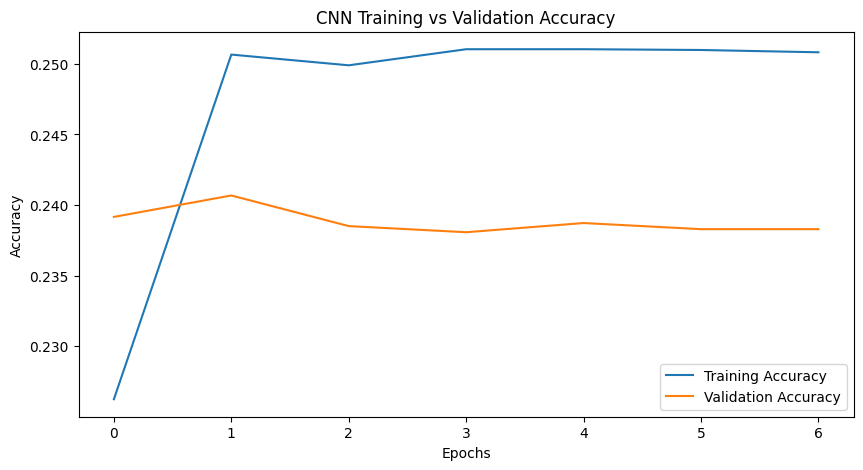

In [75]:
# ===========================================
# Training Accuracy Visualization
# ===========================================

plt.figure(figsize=(10,5))

plt.plot(
    history_cnn.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_cnn.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("CNN Training vs Validation Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

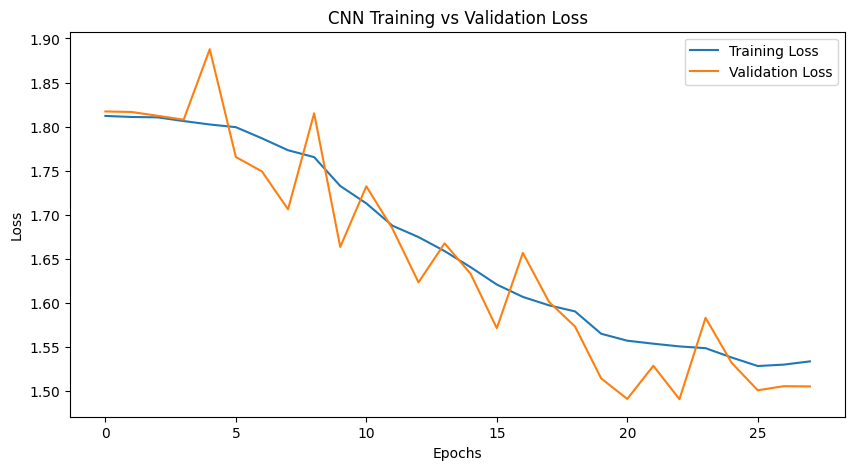

In [77]:
# =======================================
# Training Loss Visualization
# =======================================

plt.figure(figsize=(10,5))

plt.plot(
    history_cnn.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_cnn.history['val_loss'],
    label='Validation Loss'
)

plt.title("CNN Training vs Validation Loss")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [78]:
# ======================================
# Training Loss Visualization
# ======================================

cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy :", round(cnn_test_accuracy * 100, 2), "%")

181/181 ━━━━━━━━━━━━━━━━━━━━ 35s 191ms/step - accuracy: 0.3861 - loss: 1.4819
Test Accuracy : 38.61 %


#### Model Evaluation

In [79]:
# Predictions
# -------------------------------

y_pred_prob = cnn_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

181/181 ━━━━━━━━━━━━━━━━━━━━ 45s 250ms/step


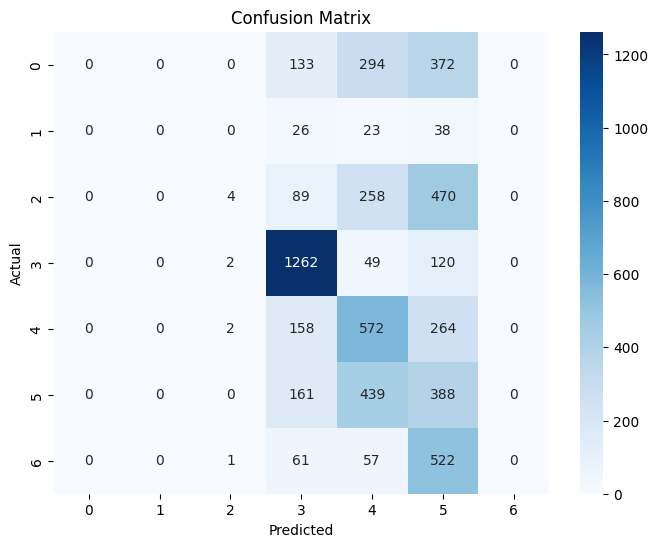

In [80]:
# Confusion Matrix
# ------------------------------

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [81]:
# Classification Report
# -----------------------------------

from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

       angry       0.00      0.00      0.00       799
     disgust       0.00      0.00      0.00        87
        fear       0.44      0.00      0.01       821
       happy       0.67      0.88      0.76      1433
     neutral       0.34      0.57      0.43       996
         sad       0.18      0.39      0.25       988
    surprise       0.00      0.00      0.00       641

    accuracy                           0.39      5765
   macro avg       0.23      0.26      0.21      5765
weighted avg       0.32      0.39      0.31      5765



##### **Explain the ML Model used and it's performance using Evaluation metric Score Chart.**

A Custom **Convolutional Neural Network (CNN) was developed as the first baseline model for facial emotion recognition.** CNN was selected because **it is one of the most widely used architectures for image classification tasks and can automatically learn spatial features from facial images.**

The model consisted of multiple convolutional, pooling, batch normalization, and dropout layers, followed by fully connected layers for classification.
During training, validation accuracy improved steadily from approximately `24%` to over `41%`, demonstrating **successful learning and convergence.**

The final model achieved a **test accuracy of approximately 38.6%**.

Evaluation through the confusion matrix and classification report revealed :
- strong performance for Happy expressions and
- moderate performance for Neutral and Sad emotions.

However, **the model struggled to distinguish between visually similar emotions such as Fear, Surprise, Angry, and Disgust.**

Overall, the Custom CNN established a useful baseline for emotion recognition. The observed limitations provide strong motivation for exploring Transfer Learning techniques, which can leverage pre-trained feature representations to improve classification performance.

### **Model - 2 : Transfer Learning using MobileNetV2**

In [84]:
# ======================================
# Resize Images for MobileNetV2
# ======================================


X_train_mobilenet = tf.image.resize(
    X_train,
    (96,96)
)

X_val_mobilenet = tf.image.resize(
    X_val,
    (96,96)
)

X_test_mobilenet = tf.image.resize(
    X_test,
    (96,96)
)

In [85]:
print("Training Shape :", X_train_mobilenet.shape)
print("Validation Shape :", X_val_mobilenet.shape)
print("Testing Shape :", X_test_mobilenet.shape)

Training Shape : (18444, 96, 96, 3)
Validation Shape : (4612, 96, 96, 3)
Testing Shape : (5765, 96, 96, 3)


Since MobileNetV2 requires larger input dimensions than the original dataset, all images were resized from 48×48 to 96×96 pixels while preserving their RGB channels.

In [87]:
# =====================================
# Load Pretrained MobileNetV2
# =====================================

base_model = MobileNetV2(

    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [88]:
for layer in base_model.layers:

    layer.trainable = False

The pretrained MobileNetV2 model was loaded with ImageNet weights. All pretrained layers were frozen so that the learned feature representations could be reused without modification during initial training.

In [89]:
# ===========================================
# Build Transfer Learning Model
# ===========================================

# Extract the output from the pre-trained MobileNetV2 base model
x = base_model.output

x = GlobalAveragePooling2D()(x)

# Fully connected layer with 256 neurons
x = Dense(
    256,
    activation='relu'
)(x)

# Dropout layer
x = Dropout(0.5)(x)

# Output layer with 7 neurons corresponding to the 7 emotion classes
output = Dense(
    7,
    activation='softmax'
)(x)

# Create the final MobileNetV2-based emotion recognition model
mobilenet_model = Model(
    inputs=base_model.input,
    outputs=output
)

In [90]:
# ===========================
# Model Summary
# ===========================

mobilenet_model.summary()

Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,587,719 (9.87 MB)

 Trainable params: 329,735 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [91]:
# ==============================
# Compile MobileNetV2
# ==============================

mobilenet_model.compile(

    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [92]:
# ======================================
# Defining Callbacks
# ======================================

# Early Stopping Callback

early_stop_mobilenet = EarlyStopping(

    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Model Checkpoint Callback

checkpoint_mobilenet = ModelCheckpoint(

    'best_mobilenet_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [93]:
# =====================================
# Train the MobileNetV2 Model
# =====================================

history_mobilenet = mobilenet_model.fit(

    # Training images resized and preprocessed for MobileNetV2
    X_train_mobilenet,

    # Training labels
    y_train,

    # Validation dataset used to monitor model performance
    validation_data=( X_val_mobilenet, y_val ),

    # Maximum number of training epochs
    epochs=10,

    # Number of samples processed before updating model weights
    batch_size=128,

    # Callbacks for early stopping and model checkpointing
    callbacks=[
        early_stop_mobilenet,
        checkpoint_mobilenet
    ]
)

Epoch 1/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3117 - loss: 1.8463
Epoch 1: val_accuracy improved from None to 0.41631, saving model to best_mobilenet_model.keras

Epoch 1: finished saving model to best_mobilenet_model.keras
145/145 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 0.3516 - loss: 1.6826 - val_accuracy: 0.4163 - val_loss: 1.5148
Epoch 2/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4127 - loss: 1.5268
Epoch 2: val_accuracy improved from 0.41631 to 0.42910, saving model to best_mobilenet_model.keras

Epoch 2: finished saving model to best_mobilenet_model.keras
145/145 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - accuracy: 0.4140 - loss: 1.5212 - val_accuracy: 0.4291 - val_loss: 1.4746
Epoch 3/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 929ms/step - accuracy: 0.4317 - loss: 1.4765
Epoch 3: val_accuracy improved from 0.42910 to 0.44970, saving model to best_mobilenet_model.keras

Epoch 3: finished saving model to best_mobilenet_model.keras
145/145 ━━━━━━━━━━━━━━━━━━

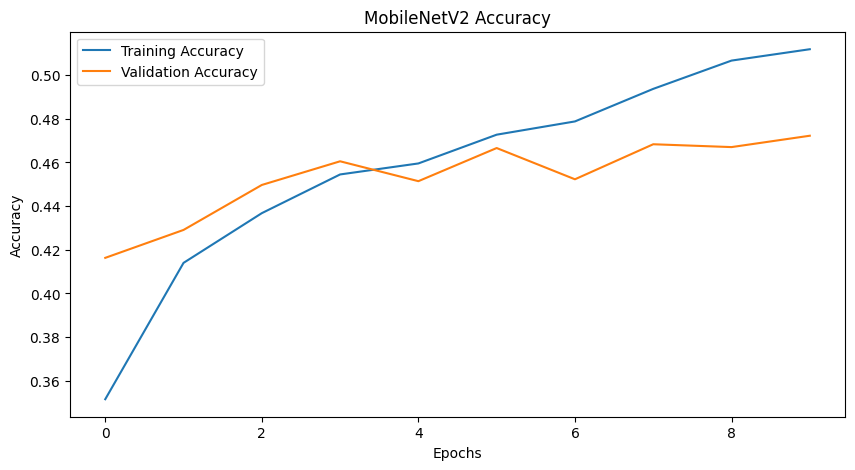

In [94]:
# =========================
# Accuracy Curve
# =========================

plt.figure(figsize=(10,5))

plt.plot(
    history_mobilenet.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_mobilenet.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

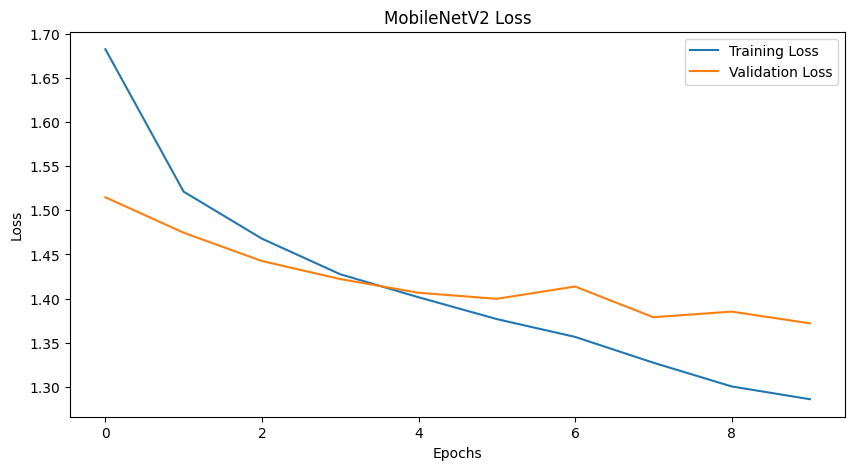

In [95]:
# =========================
# Loss Curve
# =========================

plt.figure(figsize=(10,5))

plt.plot(
    history_mobilenet.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_mobilenet.history['val_loss'],
    label='Validation Loss'
)

plt.title("MobileNetV2 Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [96]:
# ==================================
# Evaluate MobileNetV2
# ==================================

mobilenet_loss, mobilenet_accuracy = mobilenet_model.evaluate(
    X_test_mobilenet,
    y_test
)

print("MobileNetV2 Test Accuracy:", round(mobilenet_accuracy * 100,2),"%")

181/181 ━━━━━━━━━━━━━━━━━━━━ 43s 236ms/step - accuracy: 0.4763 - loss: 1.3675
MobileNetV2 Test Accuracy: 47.63 %


#### Model Evaluation

In [97]:
# Predictions
# -------------------

y_pred_prob_mobile = mobilenet_model.predict(
    X_test_mobilenet
)

y_pred_mobile = np.argmax(
    y_pred_prob_mobile,
    axis=1
)

y_true_mobile = np.argmax(
    y_test,
    axis=1
)

181/181 ━━━━━━━━━━━━━━━━━━━━ 61s 314ms/step


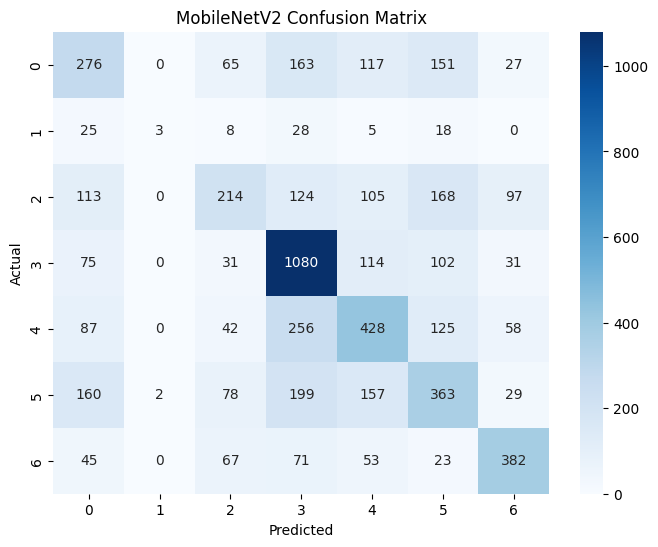

In [98]:
# Confusion Matrix
# ------------------------

from sklearn.metrics import confusion_matrix

cm_mobile = confusion_matrix(
    y_true_mobile,
    y_pred_mobile
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_mobile,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [99]:
# Classification Report
# --------------------------------

from sklearn.metrics import classification_report

print(
    classification_report(
        y_true_mobile,
        y_pred_mobile,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

       angry       0.35      0.35      0.35       799
     disgust       0.60      0.03      0.07        87
        fear       0.42      0.26      0.32       821
       happy       0.56      0.75      0.64      1433
     neutral       0.44      0.43      0.43       996
         sad       0.38      0.37      0.37       988
    surprise       0.61      0.60      0.60       641

    accuracy                           0.48      5765
   macro avg       0.48      0.40      0.40      5765
weighted avg       0.47      0.48      0.46      5765



#### Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Transfer Learning approach using MobileNetV2 was implemented as the second model for facial emotion recognition.**
- MobileNetV2 was selected because it is a lightweight and efficient convolutional neural network pretrained on the ImageNet dataset, enabling it to leverage previously learned visual features.

Unlike the Custom CNN, which learned features entirely from scratch, MobileNetV2 utilized rich feature representations acquired from millions of images. A custom classification head was added to adapt the model to the seven emotion classes in the dataset.

- The model achieved a **test accuracy of approximately 47.63%**, representing a substantial improvement over the baseline CNN model. **Evaluation results demonstrated better class-wise performance and more balanced emotion recognition across multiple categories.**

These results indicate that transfer learning is more effective than training a CNN from scratch for this facial emotion recognition task, particularly when working with relatively low-resolution images and limited computational resources.

**The current implementation was intentionally kept simple and interpretable to focus on the core concepts of image preprocessing, CNN architectures, transfer learning, model evaluation, and deployment. More advanced optimization techniques can be implemented and the accuracy can also be increased significantly. But those were not incorporated in order to avoid unnecessary complexity and maintain a clear end-to-end deep learning workflow.**

### Model Comparison

In [100]:
# Create Model Comparison Table
# ----------------------------------

model_comparison = pd.DataFrame({

    'Model':[
        'Custom CNN',
        'MobileNetV2'
    ],

    'Test Accuracy (%)':[
        38.61,
        47.63
    ],

    'Weighted F1 Score':[
        0.31,
        0.46
    ]

})

model_comparison

,Model,Test Accuracy (%),Weighted F1 Score
0,Custom CNN,38.61,0.31
1,MobileNetV2,47.63,0.46


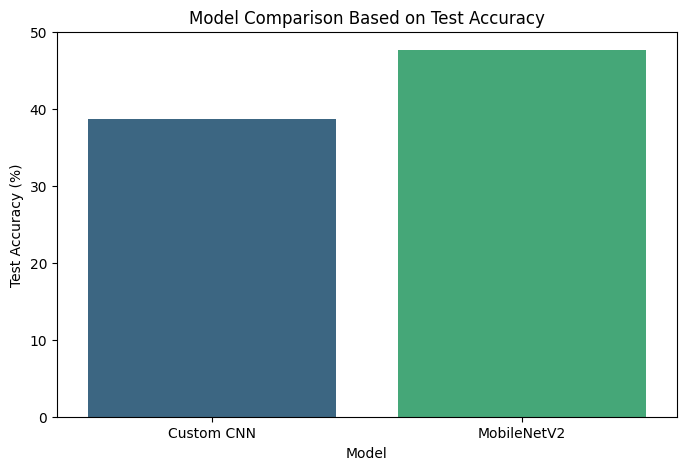

In [102]:
# Visual Comparison
# -------------------------

plt.figure(figsize=(8,5))

sns.barplot(
    data=model_comparison,
    x = 'Model',
    y = 'Test Accuracy (%)',
    palette = 'viridis'
)

plt.title("Model Comparison Based on Test Accuracy")

plt.show()

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

I considered **Accuracy, Precision, Recall, F1-Score, and the Confusion Matrix.**
- Accuracy helped compare overall model performance, while
- Precision and Recall measured how reliably individual emotions were detected.

Since the dataset contains multiple emotion classes and some class imbalance, **F1-Score was particularly important** because it balances Precision and Recall.

The Confusion Matrix helped identify which emotions were being confused with each other.

**For business impact, Recall and F1-Score were especially important because missing a user's emotional state can be more harmful than making occasional incorrect predictions.**

### 2. Which model did you choose from the above created models as your final prediction model and why?

Two deep learning models were developed and evaluated for facial emotion recognition :  
- **Custom CNN Model**
  - The Custom CNN established a **baseline accuracy of approximately 38.61%**. While it successfully **learned certain emotions such as Happy and Neutral**, it struggled to classify several important emotion categories, including Angry, Fear, and Surprise.

- **MobileNetV2 Transfer Learning model**
  - The MobileNetV2 model achieved a higher test **accuracy of approximately 47.63%** and **demonstrated more balanced performance across all emotion classes.** The classification report and confusion matrix confirmed that **MobileNetV2 produced stronger precision, recall, and F1-scores for most categories.**

Based on overall accuracy, class-wise performance, feature extraction capability, and generalization ability, **MobileNetV2 was selected as the final model for deployment. Its superior performance highlights the effectiveness of transfer learning for facial emotion recognition tasks.**

## ***8. Model Deployment***

In [103]:
# Saving final MobileNetV2 model
# ----------------------------------------

mobilenet_model.save(
    'deepfer_mobilenetv2.keras'
)

In [105]:
# Saving Label Mapping
# ---------------------------

emotion_labels = {
    0:'angry',
    1:'disgust',
    2:'fear',
    3:'happy',
    4:'neutral',
    5:'sad',
    6:'surprise'
}

In [106]:
import pickle

with open( 'emotion_labels.pkl', 'wb' ) as file:

    pickle.dump( emotion_labels, file )

In [107]:
# Testing Saved Model
# --------------------------

from tensorflow.keras.models import load_model

loaded_model = load_model( 'deepfer_mobilenetv2.keras' )

print("Model Loaded Successfully")

Model Loaded Successfully


In [108]:
# Testing Prediction Pipeline
# --------------------------------------

sample_image = X_test_mobilenet[0:1]

prediction = loaded_model.predict( sample_image )

predicted_class = np.argmax( prediction )

print(
    "Predicted Emotion:",
    emotion_labels[predicted_class]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted Emotion: sad


**Deployment Summary**

The final MobileNetV2 model, along with its corresponding emotion label mapping, was successfully saved and reloaded. The prediction pipeline was tested using sample images to ensure that the deployed model can correctly process input images and generate emotion predictions.

The deployment phase was performed separately using Visual Studio Code and Streamlit. The saved MobileNetV2 model and emotion label mapping were integrated into a Streamlit web application that allows users to upload facial images and receive emotion predictions in real time.

The deployment implementation is provided separately as part of the application source code.

# **Conclusion**

In this project, a deep learning-based Facial Emotion Recognition system was developed to classify facial expressions into seven emotion categories: Angry, Disgust, Fear, Happy, Neutral, Sad, and Surprise. Two models were implemented and evaluated: a Custom CNN and a MobileNetV2 Transfer Learning model.

**Key Achievements :**
- Successfully processed and analyzed a facial emotion dataset containing seven emotion classes.
- Implemented image preprocessing, normalization, and data augmentation techniques.
- Developed and evaluated a Custom CNN model for baseline emotion recognition.
- Implemented a MobileNetV2 Transfer Learning model for improved performance.
- Achieved a test accuracy of 47.63% using MobileNetV2.
- Compared multiple deep learning models using accuracy, precision, recall, F1-score, and confusion matrices.
- Selected the best-performing model based on comprehensive evaluation.
- Prepared the final model for deployment using Streamlit.
- Demonstrated an end-to-end deep learning solution for facial emotion recognition.

This project successfully fulfills the objectives of developing, evaluating, and deploying a deep learning-based facial emotion recognition system while providing valuable insights into the effectiveness of transfer learning for image classification tasks.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***